# Generated dataset — decomposition across CONFIGS

Results of `scripts/generated_config_study.py`: one GENERATED dataset leaf (default
`MIT_GENERATED/neg_shadow_light`) decomposed under an array of configs
(`results/generated_config_study/<domain>/<gen_cfg>/<scene>/<config>`). Marigold GT (no GT
lighting), so metrics are albedo / roughness / metallic / recon RMSE vs GT and relighting is a
synthetic sweep of the estimated intrinsics.

- **§2** metrics across configs.
- **§3–4** per-scene intrinsic maps (GT vs each config).
- **§5** on-demand relight video comparing the configs (GT + each config, one panel each).

Run the study first: `python scripts/generated_config_study.py`.

In [1]:
import sys, os, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

p = Path.cwd()
while not (p / "idr").is_dir() and p != p.parent:
    p = p.parent
os.chdir(p); sys.path[:0] = [str(p), str(p / "scripts")]
print("repo:", p)

from PIL import Image
import torch
from canonical_relight_render import (Relighter, load_est_intrinsics, load_gt_intrinsics,
    _write_mp4, _tonemap_fn, _upscale, _label)

# point at the study leaf you ran (domain/gen_cfg)
STUDY  = p / "results" / "generated_config_study" / "MIT" / "neg_shadow_light"
# STUDY =  p / "results" / "generated_config_study" / "?" / "INFINITE"
DEVICE = "cuda"            # "cpu" if the GPU is busy
print("study:", STUDY, "| exists:", STUDY.exists())

repo: /home/felix/Projects/image-intrinsics
study: /home/felix/Projects/image-intrinsics/results/generated_config_study/MIT/neg_shadow_light | exists: True


## 1. Load results

In [2]:
rows = []
for rp in sorted(STUDY.glob("*/*/results.json")):     # <scene>/<config>
    scene, config = rp.parts[-3:-1]
    r = json.loads(rp.read_text()); m = r.get("metrics", {})
    rows.append(dict(scene=scene, config=config, ds=int(r.get("ds", 1)),
                     albedo_rmse=m.get("albedo_rmse"), roughness_rmse=m.get("roughness_rmse"),
                     metallic_rmse=m.get("metallic_rmse"), recon_rmse=m.get("recon_rmse"),
                     out_dir=r.get("out_dir", str(rp.parent)), scene_dir=r.get("scene_dir")))
df = pd.DataFrame(rows)
assert len(df), f"no results under {STUDY} — run scripts/generated_config_study.py first"
METRICS = ["albedo_rmse", "roughness_rmse", "metallic_rmse", "recon_rmse"]
display(df[["scene", "config", "ds"] + METRICS].round(4))

,scene,config,ds,albedo_rmse,roughness_rmse,metallic_rmse,recon_rmse
0,everett_dining1,metallic_l1_seg_tv_albedo_light_mono,4,0.2830,0.3084,0.3473,0.0694
1,everett_dining1,metallic_l1_seg_tv_all,4,0.2763,0.4026,0.3623,0.0611
2,everett_dining1,metallic_l1_seg_tv_all_light_mono,4,0.2582,0.2578,0.3448,0.0711
3,everett_dining1,metallic_l1_seg_tv_metallic_roughness_light_mono,4,0.2676,0.2717,0.3427,0.0695
4,everett_dining1,metallic_l1_tv_all_light_mono,4,0.2810,0.3518,0.3501,0.0652
5,everett_dining1,seg_tv_all_light_mono,4,0.2911,0.4962,0.6511,0.0574
6,everett_kitchen12,metallic_l1_seg_tv_albedo_light_mono,4,0.2206,0.3305,0.3353,0.0758
7,everett_kitchen12,metallic_l1_seg_tv_all,4,0.2593,0.3634,0.3423,0.0718
8,everett_kitchen12,metallic_l1_seg_tv_all_light_mono,4,0.2225,0.3180,0.3381,0.0766
9,everett_kitchen12,metallic_l1_seg_tv_metallic_roughness_light_mono,4,0.2195,0.3178,0.3391,0.0755


## 2. Metrics across configs

Mean over scenes; one panel per metric. Lower is better.

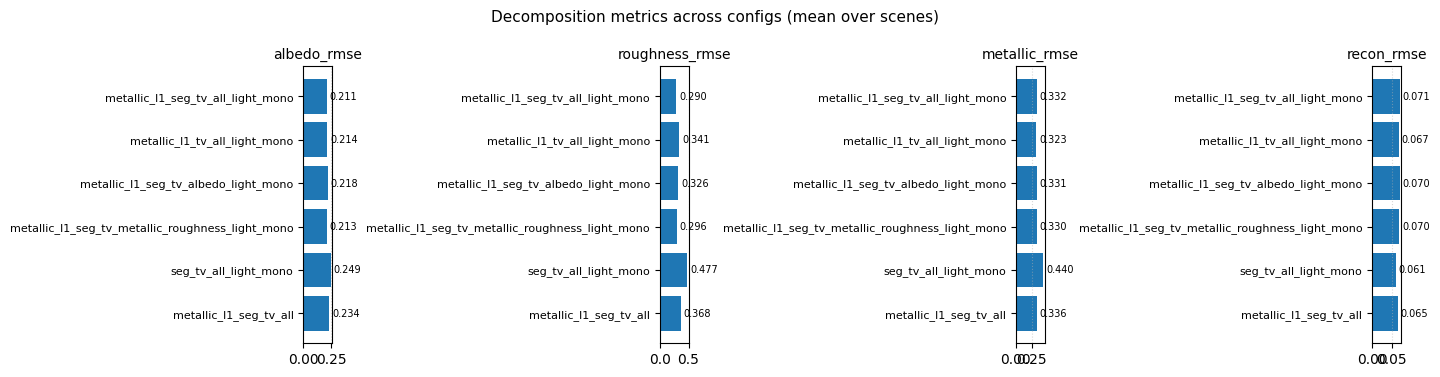

In [4]:
import scripts.generated_config_study as CS
order = [c for c in CS.CONFIGS if c in df["config"].unique()] + \
        [c for c in df["config"].unique() if c not in CS.CONFIGS]
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.6 * len(METRICS), 3.8))
axes = np.atleast_1d(axes)
g = df.groupby("config")[METRICS].mean()
y = np.arange(len(order))
for ax, met in zip(axes, METRICS):
    vals = [g.loc[c, met] if c in g.index else np.nan for c in order]
    b = ax.barh(y, vals); ax.bar_label(b, fmt="%.3f", fontsize=7, padding=2)
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.invert_yaxis()
    ax.set_title(met, fontsize=10); ax.grid(axis="x", ls=":", alpha=0.5)
fig.suptitle("Decomposition metrics across configs (mean over scenes)", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Pick a scene

In [8]:
SCENE = sorted(df["scene"].unique())[3]
sub = df[df.scene == SCENE].set_index("config")
DS = int(sub["ds"].iloc[0]); SCENE_DIR = Path(sub["scene_dir"].iloc[0])
CONFIGS_SHOWN = [c for c in order if c in sub.index]
runs = {c: Path(sub.loc[c, "out_dir"]) for c in CONFIGS_SHOWN}
print("scene:", SCENE, "| ds:", DS, "| configs:", CONFIGS_SHOWN)

scene: marlborough_kitchen1 | ds: 4 | configs: ['metallic_l1_seg_tv_all_light_mono', 'metallic_l1_tv_all_light_mono', 'metallic_l1_seg_tv_albedo_light_mono', 'metallic_l1_seg_tv_metallic_roughness_light_mono', 'seg_tv_all_light_mono', 'metallic_l1_seg_tv_all']


## 4. Intrinsics — GT vs each config

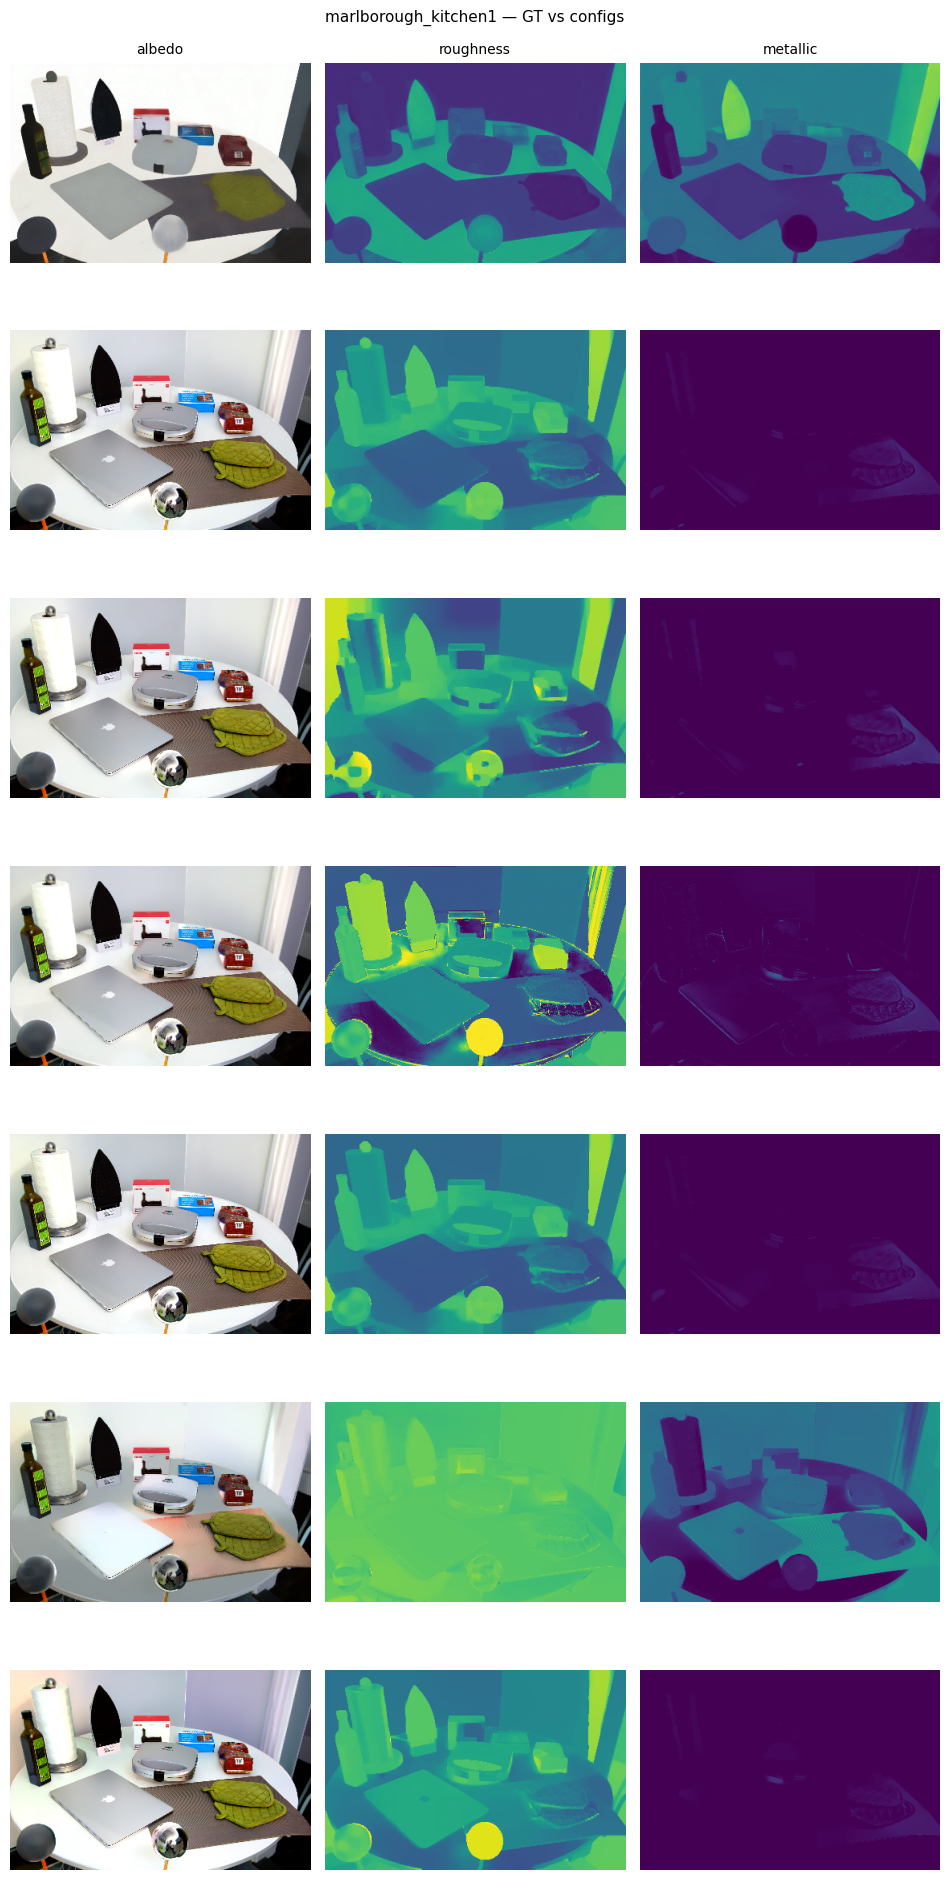

In [9]:
gt = load_gt_intrinsics(SCENE_DIR, DS); mask = gt["mask"]
maps = ["albedo", "roughness", "metallic"]
rows_ = [("GT", gt)] + [(c, load_est_intrinsics(runs[c])) for c in CONFIGS_SHOWN]
fig, ax = plt.subplots(len(rows_), len(maps), figsize=(3.2 * len(maps), 2.8 * len(rows_)))
ax = np.atleast_2d(ax)
for i, (name, src) in enumerate(rows_):
    for j, k in enumerate(maps):
        mmap = src[k]; mmap = mmap if mmap.ndim == 3 else mmap[..., None].repeat(3, -1)
        disp = np.clip(mmap, 0, 1).copy(); disp[~mask] = 1.0
        if k == "albedo": ax[i, j].imshow(disp)
        else: ax[i, j].imshow(disp[..., 0], cmap="viridis", vmin=0, vmax=1)
        ax[i, j].axis("off")
        if i == 0: ax[i, j].set_title(k, fontsize=10)
    ax[i, 0].set_ylabel(name, fontsize=9, rotation=0, ha="right", va="center")
fig.suptitle(f"{SCENE} — GT vs configs", fontsize=11)
plt.tight_layout(); plt.show()

## 5. Relight video — GT vs configs (on demand)

Relights GT + each selected config's estimated intrinsics through identical geometry under one
azimuth sweep (shared tonemap), one panel each. Edit `VID_CONFIGS` to choose which to include.

In [10]:
VID_CONFIGS = CONFIGS_SHOWN          # e.g. ["base", "seg_tv"]
def configs_relight_video(scene_dir, runs, configs, ds, mode="env_sharp", az_from=-45, az_to=45,
                          n_frames=41, device=DEVICE, fps=18, el=45.0, panel_px=256):
    gt = load_gt_intrinsics(scene_dir, ds)
    panels = [("GT", gt)] + [(c, load_est_intrinsics(runs[c])) for c in configs]
    rel = Relighter(gt["normals"], gt["mask"], device, torch.float32, True)
    kw = dict(sigma_deg=4.0) if mode == "env_sharp" else {}
    az = np.linspace(az_from, az_to, n_frames)
    seq = {name: [rel.render(intr, mode, a, el, **kw) for a in az] for name, intr in panels}
    tm = _tonemap_fn([f for fr in seq.values() for f in fr])
    frames = []
    for i, a in enumerate(az):
        strip = [_label(_upscale(tm(seq[name][i]), panel_px), f"{name} az={a:+.0f}") for name, _ in panels]
        frames.append(np.concatenate(strip, axis=1))
    stem = str(runs[configs[0]].parent / f"relight_configs_{mode}")
    return _write_mp4(frames, stem, fps=fps, ping_pong=True)

from IPython.display import Video, Image as IPyImage
vid = configs_relight_video(SCENE_DIR, runs, VID_CONFIGS, DS)
print("wrote", vid)
display(Video(vid, embed=True, width=min(260 * (len(VID_CONFIGS) + 1), 1200))
        if vid.endswith(".mp4") else IPyImage(vid))

wrote /home/felix/Projects/image-intrinsics/results/generated_config_study/MIT/neg_shadow_light/marlborough_kitchen1/relight_configs_env_sharp.mp4
